# EDA of North Atlantic Basin part of ME4OH dataset - using SVD

Goal: To use SVD to reconstruct a low-rank approximation of OHC

Data subset:
- North Atlantic basin
- January 1993
    - Any duplicated lat/long values have been dropped (loses 786 out of 1538 data points)

In [1]:
import numpy as np
import pandas as pd

from plotting_functions import plot_ohc_map

## Load data

In [2]:
df = pd.read_csv("Data/ME4OH_EN411_OFAM3/NA_1993_2014.csv")

## Preprocessing

In [3]:
# Convert dates to datetime, save year month and year indication columns (aids plotting)
df['Date'] = pd.to_datetime(df['Date'])
df['year_month'] = df['Date'].dt.to_period('M')
df['year'] = df['Date'].dt.to_period('Y')
df

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number,year_month,year
0,1993-01-01,10.05,-27.950012,0.364007,-0.048830,401,WOD09XBTDE 329,14105829,1993-01,1993
1,1993-01-01,9.05,-28.350006,0.364593,-0.037233,401,WOD09XBTDE 329,14105829,1993-01,1993
2,1993-01-01,6.25,-31.350006,0.366382,0.043336,401,WOD09XBTPA 123,14302123,1993-01,1993
3,1993-01-01,56.55,-20.149994,0.356725,-0.522782,401,WOD09XBTGB 5966,11394866,1993-01,1993
4,1993-01-01,36.25,-8.549988,0.364267,-0.377209,401,WOD09XBT99,0,1993-01,1993
...,...,...,...,...,...,...,...,...,...,...
814193,2014-12-31,16.45,-78.350006,0.373563,0.350963,831,ARGOA,4902067,2014-12,2014
814194,2014-12-31,2.45,-25.149994,0.366325,0.030519,831,ARGOR,1901722,2014-12,2014
814195,2014-12-31,37.55,-68.950012,0.370469,0.210578,831,ARGOR,4901278,2014-12,2014
814196,2014-12-31,4.75,-27.350006,0.366465,0.026551,831,ARGOR,1901684,2014-12,2014


In [4]:
# Get project type
project_type_list = []
for name in df['Project name']:
    for t in ['ARGO', 'ABSO', 'WOD', 'GTSPP']:
        if t in name:
            project_type_list.append(t)
df['Project type'] = project_type_list
df

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number,year_month,year,Project type
0,1993-01-01,10.05,-27.950012,0.364007,-0.048830,401,WOD09XBTDE 329,14105829,1993-01,1993,WOD
1,1993-01-01,9.05,-28.350006,0.364593,-0.037233,401,WOD09XBTDE 329,14105829,1993-01,1993,WOD
2,1993-01-01,6.25,-31.350006,0.366382,0.043336,401,WOD09XBTPA 123,14302123,1993-01,1993,WOD
3,1993-01-01,56.55,-20.149994,0.356725,-0.522782,401,WOD09XBTGB 5966,11394866,1993-01,1993,WOD
4,1993-01-01,36.25,-8.549988,0.364267,-0.377209,401,WOD09XBT99,0,1993-01,1993,WOD
...,...,...,...,...,...,...,...,...,...,...,...
814193,2014-12-31,16.45,-78.350006,0.373563,0.350963,831,ARGOA,4902067,2014-12,2014,ARGO
814194,2014-12-31,2.45,-25.149994,0.366325,0.030519,831,ARGOR,1901722,2014-12,2014,ARGO
814195,2014-12-31,37.55,-68.950012,0.370469,0.210578,831,ARGOR,4901278,2014-12,2014,ARGO
814196,2014-12-31,4.75,-27.350006,0.366465,0.026551,831,ARGOR,1901684,2014-12,2014,ARGO


In [5]:
df['Project type'].value_counts()

Project type
WOD      455230
ARGO     325764
GTSPP     33204
Name: count, dtype: int64

In [6]:
# Filter for a single month
df = df[df["year_month"]=="1993-01"]
df

,Date,Latitude,Longitude,OHC,SSH,WMO Instrument Type,Project name,Platform number,year_month,year,Project type
0,1993-01-01,10.05,-27.950012,0.364007,-0.048830,401,WOD09XBTDE 329,14105829,1993-01,1993,WOD
1,1993-01-01,9.05,-28.350006,0.364593,-0.037233,401,WOD09XBTDE 329,14105829,1993-01,1993,WOD
2,1993-01-01,6.25,-31.350006,0.366382,0.043336,401,WOD09XBTPA 123,14302123,1993-01,1993,WOD
3,1993-01-01,56.55,-20.149994,0.356725,-0.522782,401,WOD09XBTGB 5966,11394866,1993-01,1993,WOD
4,1993-01-01,36.25,-8.549988,0.364267,-0.377209,401,WOD09XBT99,0,1993-01,1993,WOD
...,...,...,...,...,...,...,...,...,...,...,...
1533,1993-01-31,6.05,-13.350006,0.365977,-0.005799,401,WOD09XBTFR 4293,11413493,1993-01,1993,WOD
1534,1993-01-31,20.65,-49.850006,0.372333,0.034181,401,WOD09XBTFR 4200,14108300,1993-01,1993,WOD
1535,1993-01-31,1.25,-22.250000,0.365645,-0.040895,401,WOD09XBTPA 121,14303521,1993-01,1993,WOD
1536,1993-01-31,8.65,-15.350006,0.365664,-0.025636,401,WOD09XBTFR 4293,11413493,1993-01,1993,WOD


In [7]:
df['Project type'].value_counts()

Project type
WOD      1440
GTSPP      98
Name: count, dtype: int64

In [8]:
df['Coordinate'] = [(df.Latitude[i], df.Longitude[i]) for i in range(len(df))]
df = df.drop_duplicates('Coordinate')

In [9]:
df['Project type'].value_counts()

Project type
WOD      704
GTSPP     48
Name: count, dtype: int64

In [10]:
# Create pivot table: rows = latitude, columns = longitude, values = OHC
orig_matrix = df.pivot_table(index="Latitude", columns="Longitude", values="OHC")
# matrix = matrix.fillna(0)  # Replace NaNs with 0
matrix = orig_matrix.fillna(orig_matrix.mean(axis=1), axis=1)  # Replace with mean value for latitude
matrix

Longitude,-79.750000,-79.450012,-76.649994,-75.549988,-74.450012,-74.350006,-74.250000,-74.149994,-74.049988,-73.950012,...,-2.549988,-2.149994,-2.049988,-1.750000,-1.350006,-0.850006,-0.750000,-0.450012,-0.350006,-0.149994
Latitude,,,,,,,,,,,,,,,,,,,,,
0.05,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,...,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031,0.367031
0.15,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,...,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902,0.366902
0.35,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,...,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747,0.366747
0.45,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,...,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595,0.367595
0.55,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,...,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999,0.367999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56.85,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,...,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332,0.356332
57.35,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,...,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512,0.356512
57.45,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,...,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750,0.356750


Thoughts: some of these latitudes/longitudes are on land and therefore it is unrealistic to have an OHC value here

In [11]:
matrix.shape

(367, 455)

In [12]:
U, S, V = np.linalg.svd(matrix)  # automatically sorts S
U.shape, S.shape, V.shape

((367, 367), (367,), (455, 455))

In [13]:
# Adjust matrix shapes to ensure U (m x n), S (n x n), V (n x n):
U = U[:, :S.shape[0]]  # Limit U to the number of singular values
S = np.diag(S)  # Convert S (a vector) into a diagonal matrix

In [14]:
k = 5  # Chosen rank
R = U[:, :k] @ S[:k, :k] @ V[:k, :]  # Use rank-reduced components for approximation 
R

array([[0.36704046, 0.36703107, 0.36703706, ..., 0.36703165, 0.36702866,
        0.36702992],
       [0.36691156, 0.3669022 , 0.36690818, ..., 0.36690278, 0.36689981,
        0.36690105],
       [0.36675673, 0.36674737, 0.36675335, ..., 0.36674795, 0.36674497,
        0.36674617],
       ...,
       [0.35675895, 0.35674983, 0.35675565, ..., 0.35675039, 0.35674749,
        0.35674871],
       [0.35594965, 0.35594055, 0.35594636, ..., 0.35594111, 0.35593822,
        0.35593943],
       [0.35493497, 0.3549259 , 0.35493169, ..., 0.35492646, 0.35492357,
        0.35492478]], shape=(367, 455))

In [15]:
# Best k wil give this ratio~0.8 (https://www.youtube.com/watch?v=c7e-D2tmRE0)
np.linalg.norm(S[:k, :k], ord='fro')/np.linalg.norm(S, ord='fro')

np.float64(0.999999940461249)

In [16]:
R.shape

(367, 455)

In [17]:
fro_error = np.linalg.norm(matrix - R, ord='fro')
norm_matrix = np.linalg.norm(matrix, ord='fro')
rel_error = fro_error / (norm_matrix if norm_matrix != 0 else 1.0)
rel_error

np.float64(0.0003450760761776531)

In [18]:
fro_error

np.float64(0.051384230852898546)

In [19]:
reconstructed_df = pd.DataFrame(R, index=matrix.index.to_list(), columns=matrix.columns.to_list())
reconstructed_df = reconstructed_df.reset_index(drop=False, names='Latitude')
# reconstructed_df

In [20]:
unpivot_reconstruct = reconstructed_df.melt(id_vars='Latitude', var_name='Longitude', value_name='OHC')
# unpivot_reconstruct

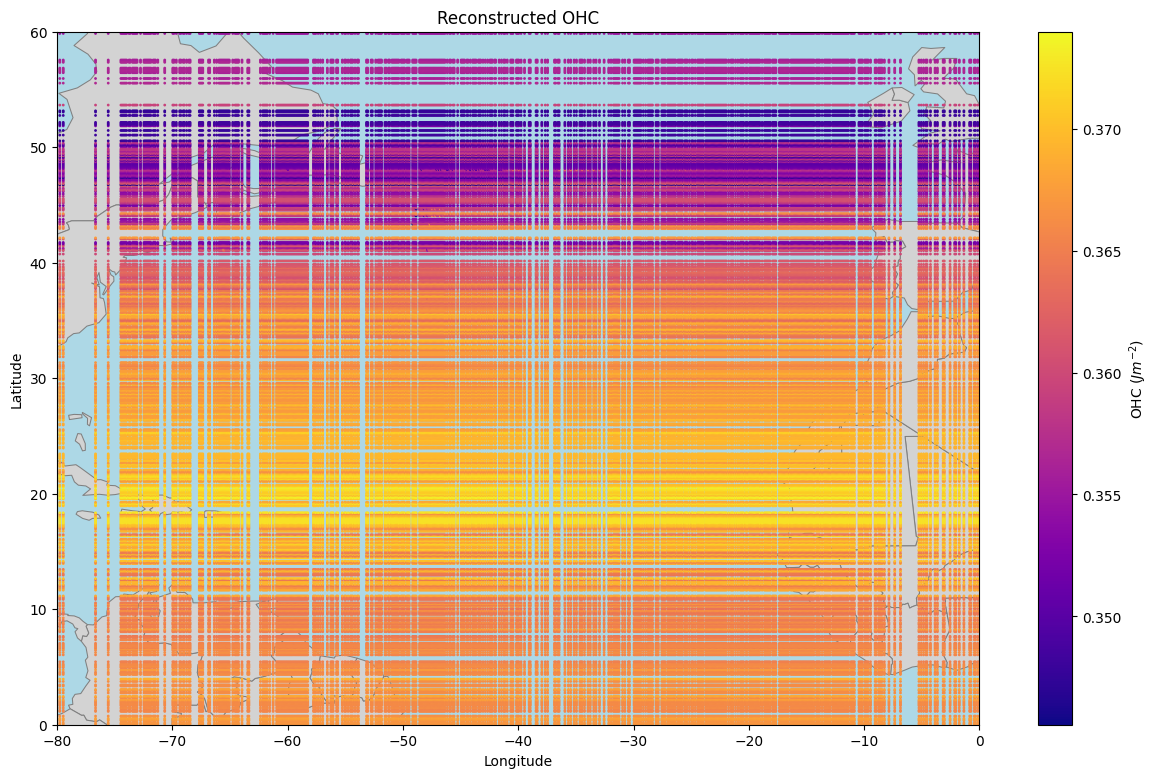

In [21]:
plot_ohc_map(unpivot_reconstruct, "Reconstructed OHC", min_ohc=min(df.OHC), max_ohc=max(df.OHC), basin="NA")

### Remove values that didn't exist in original dataset

In [ ]:
# Set index and columns of original data matrix so match R
orig_matrix = orig_matrix.reset_index(drop=True)
orig_matrix.columns = range(orig_matrix.columns.size)

In [36]:
# Mask out values that were NaN in original
R_df = pd.DataFrame(R)
R_masked = R_df.mask(orig_matrix.isnull())
# R_masked

In [39]:
# verifications
print(orig_matrix.isnull().sum().sum() == R_masked.isnull().sum().sum()) # Check that the number of NaNs has been preserved
print(R_masked.isnull().sum().sum() != 367*455)  # Check that not all data is NaN

True
True


In [ ]:
# Reset columns and rows (index) to be lat/long values
R_masked.columns = matrix.columns.to_list()
R_masked["Latitude"] = matrix.index.to_list()
# R_masked

# Unpivot data (revert to original format, with lat, long and OHC in separate columns) + drop NaNs (masked out data points)
masked_unpivot_df = R_masked.melt(id_vars='Latitude', var_name='Longitude', value_name='OHC').dropna().reset_index(drop=True)
# masked_unpivot_df

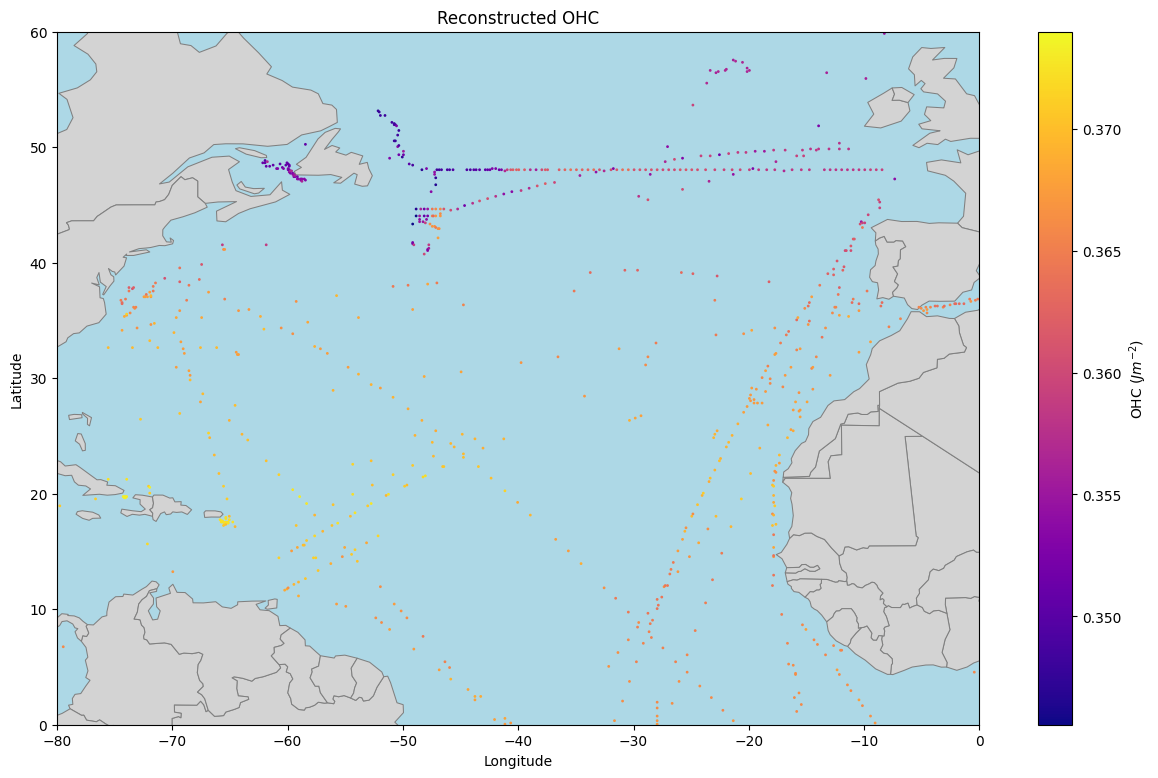

In [30]:
plot_ohc_map(masked_unpivot_df, "Reconstructed OHC", min_ohc=min(df.OHC), max_ohc=max(df.OHC), basin="NA")